# Side Event A — Coinbase 직상장 (2021-04-14)
## 스토리텔링 차트 (Scrollytelling Stepper)

### 배경
2021년 4월 14일, 코인베이스(COIN)가 Nasdaq에 **직상장(Direct Listing)**. IPO처럼 신주를 발행하지 않고 기존 주주가 바로 매도하는 방식. Reference price $250으로 시작해 **Open $381 / High $429.54 / Close $328.28**로 첫 날을 마감. 종가 기준 **시총 약 $1,120억** — 2012년 Facebook IPO($1,040억)를 넘어서는 역대 최대급 규모.

### 이 사건이 "사이드"인 이유
단일 기업 이벤트이지만 **암호화폐 제도권 편입의 상징**이자 **사이클 정점의 신호**였다. 실제로 BTC는 상장 전날 ATH $63,503을 찍고 이후 -50% 조정이 시작됐다.

### 출력
- `data/figures/eA_story/00_prologue.png` … `05_act5.png`
- `data/figures/eA_story/99_summary.png`

## 1. Imports & 경로 설정

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path(os.getcwd()).parent
COIN_PATH  = ROOT / 'data' / 'raw' / 'COIN.csv'
PANEL_PATH = ROOT / 'data' / 'processed' / 'panel_daily.csv'
FIG_DIR    = ROOT / 'data' / 'figures' / 'eA_story'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'ROOT     : {ROOT}')
print(f'FIG_DIR  : {FIG_DIR}')

ROOT     : c:\Users\kimch\Desktop\project\pandemic-finance
FIG_DIR  : c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\eA_story


## 2. 데이터 로드

- **COIN**: 원본 `COIN.csv`에서 3행 헤더 건너뛰고 파싱. 상장 이전 데이터는 존재하지 않으므로 4/14부터 자연스럽게 시작된다.
- **BTC-USD**: `panel_daily.csv`에서 연속 데이터로 로드.

In [2]:
# --- COIN (raw Yahoo dump: Price/Adj Close/Close/High/Low/Open/Volume 헤더 3줄) ---
coin_raw = pd.read_csv(
    COIN_PATH, skiprows=3, header=None,
    names=['Date', 'AdjClose', 'Close', 'High', 'Low', 'Open', 'Volume'],
    parse_dates=['Date'], index_col='Date',
)
coin = coin_raw.loc['2021-04-14':'2021-05-14', ['Open', 'High', 'Low', 'Close']].copy()

# --- BTC (연속) ---
panel = pd.read_csv(PANEL_PATH, index_col=0, parse_dates=True)
btc = panel.loc['2021-03-15':'2021-05-14', 'BTC-USD'].copy()

print(f'COIN  : {coin.shape}, {coin.index.min().date()} ~ {coin.index.max().date()}')
print(f'BTC   : {btc.shape}, {btc.index.min().date()} ~ {btc.index.max().date()}')
print()
print('COIN 상장일 OHLC:')
print(coin.iloc[0])
print()
print(f'BTC ATH   : ${btc.max():,.0f}  on  {btc.idxmax().date()}')
print(f'BTC 저점  : ${btc.min():,.0f}  on  {btc.idxmin().date()}')
print(f'COIN 저점 : ${coin.Close.min():,.2f}  on  {coin.Close.idxmin().date()}')

COIN  : (23, 4), 2021-04-14 ~ 2021-05-14
BTC   : (45,), 2021-03-15 ~ 2021-05-14

COIN 상장일 OHLC:
Open     381.000000
High     429.540009
Low      310.000000
Close    328.279999
Name: 2021-04-14 00:00:00, dtype: float64

BTC ATH   : $63,503  on  2021-04-13
BTC 저점  : $49,151  on  2021-05-12
COIN 저점 : $256.76  on  2021-05-06


## 3. 6국면 정의

In [3]:
phases = [
    {
        'id': 'prologue', 'name': 'Prologue — 기대의 절정',
        'start': '2021-03-15', 'end': '2021-04-09', 'color': '#64B5F6',
        'narrative': 'Coinbase 직상장을 한 달 앞두고 "암호화폐 제도권 편입" 서사가 절정. BTC는 $55K~$60K 박스권에서 기대감을 누적했다.',
        'hero_annotations': [
            ('2021-03-15', 'BTC', 55907, '기대 랠리 시작\n$56K', (-50, 25), 'left'),
            ('2021-04-09', 'BTC', 58245, '상장 1주 전\n$58K', (15, -30), 'left'),
        ],
    },
    {
        'id': 'act1', 'name': 'Act 1 — BTC 사상 최고',
        'start': '2021-04-12', 'end': '2021-04-13', 'color': '#FFB74D',
        'narrative': '상장 전날(4/13) BTC가 사상 최고 $63,503을 기록. 시장은 축제 무드 — Coinbase 상장은 암호화폐 승리의 상징이 되었다.',
        'hero_annotations': [
            ('2021-04-13', 'BTC', 63503, 'BTC 사상 최고\n$63,503\n(상장 전날)', (15, 20), 'left'),
        ],
    },
    {
        'id': 'act2', 'name': 'Act 2 — The Listing Day',
        'start': '2021-04-14', 'end': '2021-04-14', 'color': '#0052FF',
        'narrative': '⭐ 2021-04-14. Reference $250으로 시작한 COIN은 Open $381 → 장중 최고 $429.54 → Close $328.28. 시총 $1,120억 — Facebook IPO(2012)를 넘어선 역대 최대급 직상장.',
        'hero_annotations': [
            ('2021-04-14', 'COIN_HIGH',  429.54, '장중 최고\n$429.54', (20, 15), 'left'),
            ('2021-04-14', 'COIN_OPEN',  381.00, 'Open $381', (20, 10), 'left'),
            ('2021-04-14', 'COIN',       328.28, 'Close $328\n시총 $1,120억', (25, -35), 'left'),
        ],
    },
    {
        'id': 'act3', 'name': 'Act 3 — 초기 냉각',
        'start': '2021-04-15', 'end': '2021-04-23', 'color': '#EF5350',
        'narrative': '상장 후 일주일, COIN과 BTC가 동반 하락. 초기 열광이 식고 차익 실현이 시작됐다.',
        'hero_annotations': [
            ('2021-04-23', 'COIN', 291.60, 'COIN -11%\n(일주일)', (-70, -40), 'left'),
            ('2021-04-23', 'BTC',  51093, 'BTC -19%\n(일주일)', (15, -30), 'left'),
        ],
    },
    {
        'id': 'act4', 'name': 'Act 4 — 2차 하락 (신저가)',
        'start': '2021-04-26', 'end': '2021-05-07', 'color': '#C62828',
        'narrative': '5월 초 COIN은 $257까지 하락. 상장일 Close 대비 -22%, 장중 High($429.54) 대비 -40%. 축제는 빠르게 식어갔다.',
        'hero_annotations': [
            ('2021-05-06', 'COIN', 256.76, '신저가 $257\n(-40% from High)', (-125, 20), 'left'),
        ],
    },
    {
        'id': 'act5', 'name': 'Act 5 — 크립토 겨울 전조',
        'start': '2021-05-10', 'end': '2021-05-14', 'color': '#616161',
        'narrative': '5/12 머스크가 "Tesla, BTC 결제 중단"을 선언하며 암호화폐 전체가 급락. 상장일의 축제는 정확히 한 달 만에 막을 내렸다.',
        'hero_annotations': [
            ('2021-05-12', 'BTC',  49150, 'Musk 트윗\nTesla BTC 중단\n(-17% 하루)', (-140, -25), 'left'),
            ('2021-05-14', 'COIN', 258.37, 'COIN $258\n(상장 +1개월)', (-110, 20), 'left'),
        ],
    },
]

pd.DataFrame([{k: v for k, v in p.items() if k != 'hero_annotations'} for p in phases])

,id,name,start,end,color,narrative
0,prologue,Prologue — 기대의 절정,2021-03-15,2021-04-09,#64B5F6,"Coinbase 직상장을 한 달 앞두고 ""암호화폐 제도권 편입"" 서사가 절정. BT..."
1,act1,Act 1 — BTC 사상 최고,2021-04-12,2021-04-13,#FFB74D,"상장 전날(4/13) BTC가 사상 최고 $63,503을 기록. 시장은 축제 무드 ..."
2,act2,Act 2 — The Listing Day,2021-04-14,2021-04-14,#0052FF,⭐ 2021-04-14. Reference $250으로 시작한 COIN은 Open ...
3,act3,Act 3 — 초기 냉각,2021-04-15,2021-04-23,#EF5350,"상장 후 일주일, COIN과 BTC가 동반 하락. 초기 열광이 식고 차익 실현이 시..."
4,act4,Act 4 — 2차 하락 (신저가),2021-04-26,2021-05-07,#C62828,"5월 초 COIN은 $257까지 하락. 상장일 Close 대비 -22%, 장중 Hi..."
5,act5,Act 5 — 크립토 겨울 전조,2021-05-10,2021-05-14,#616161,"5/12 머스크가 ""Tesla, BTC 결제 중단""을 선언하며 암호화폐 전체가 급락..."


## 4. 공통 상수 & 헬퍼

- **COIN 패널 특수 처리**: 상장 이전 구간은 실제 데이터가 없다. $250 가로 점선(Reference Price)으로 "아직 상장 전"을 시각화.
- **Hero annotation 타깃 확장**: `COIN`, `COIN_OPEN`, `COIN_HIGH`, `BTC` 4종. OPEN/HIGH는 상장일에만 찍히는 특수 마커.

In [4]:
XLIM       = (pd.Timestamp('2021-03-15'), pd.Timestamp('2021-05-14'))
YLIM_COIN  = (230, 450)
YLIM_BTC   = (47000, 66000)
DIM_COLOR  = '#D0D0D0'
REF_PRICE  = 250.0
LISTING_DATE = pd.Timestamp('2021-04-14')


def plot_coin_panel(ax, visible_end, phase):
    # 1) 레퍼런스 가격 가로선 (상장 전을 상징)
    ax.axhline(REF_PRICE, color='#455A64', linestyle='--', lw=1.3, alpha=0.75, zorder=1)
    ax.text(XLIM[0], REF_PRICE + 3, '  Reference $250 (상장 전)',
            fontsize=9, color='#455A64', fontweight='bold', va='bottom')

    # 2) COIN Close 라인 (상장 이후만 존재)
    mask_v = coin.index <= visible_end
    if mask_v.any():
        xv, yv = coin.index[mask_v], coin['Close'][mask_v]

        # 배경 디밍
        ax.plot(xv, yv, color=DIM_COLOR, lw=1.5, alpha=0.85, zorder=2,
                marker='o', markersize=3)

        # 활성 구간 오버레이
        ps = pd.Timestamp(phase['start'])
        pe = pd.Timestamp(phase['end']) + pd.Timedelta(days=1)
        mask_a = (xv >= ps) & (xv <= pe)
        if mask_a.any():
            ax.plot(xv[mask_a], yv[mask_a], color=phase['color'], lw=3.2, zorder=5,
                    marker='o', markersize=6, markerfacecolor=phase['color'],
                    markeredgecolor='white', markeredgewidth=1.3)

    # 3) 상장일 OHLC 오차막대 (가는 회색 세로선)
    d0 = LISTING_DATE
    if d0 <= visible_end and d0 in coin.index:
        row = coin.loc[d0]
        ax.vlines(d0, row['Low'], row['High'], colors='#999', lw=1.2,
                  alpha=0.7, zorder=3)

    ax.set_ylabel('COIN 종가 ($)', fontsize=10.5, fontweight='bold', color='#333')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.2, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def plot_btc_panel(ax, visible_end, phase):
    mask_v = btc.index <= visible_end
    xv, yv = btc.index[mask_v], btc[mask_v]

    ax.plot(xv, yv, color=DIM_COLOR, lw=1.5, alpha=0.85, zorder=2)

    ps = pd.Timestamp(phase['start'])
    pe = pd.Timestamp(phase['end']) + pd.Timedelta(days=1)
    mask_a = (xv >= ps) & (xv <= pe)
    if mask_a.any():
        ax.plot(xv[mask_a], yv[mask_a], color=phase['color'], lw=3.2, zorder=5,
                marker='o', markersize=5, markerfacecolor=phase['color'],
                markeredgecolor='white', markeredgewidth=1.2)

    ax.set_ylabel('Bitcoin ($)', fontsize=10.5, fontweight='bold', color='#333')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.2, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # K 단위 포맷
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))


def draw_frame(idx, show_future=False):
    phase = phases[idx]
    phase_end = pd.Timestamp(phase['end'])
    visible_end = XLIM[1] if show_future else phase_end + pd.Timedelta(days=2)

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 1, height_ratios=[0.35, 1.6, 1.4], hspace=0.18)
    ax_rib  = fig.add_subplot(gs[0])
    ax_coin = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_btc  = fig.add_subplot(gs[2], sharex=ax_rib)

    # Ribbon
    for i, p in enumerate(phases):
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        active = (i == idx)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.95 if active else 0.18)
        short = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short,
                    ha='center', va='center',
                    fontsize=10 if active else 8.5,
                    fontweight='bold' if active else 'normal',
                    color='#111' if active else '#AAA')
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top', 'right', 'bottom', 'left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    # Title & narrative
    fig.suptitle(f'[{idx+1}/6]  {phase["name"]}',
                 fontsize=16, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.93, phase['narrative'],
             ha='center', va='top', fontsize=11.5, color='#333',
             style='italic', wrap=True)

    # 패널
    plot_coin_panel(ax_coin, visible_end, phase)
    plot_btc_panel(ax_btc, visible_end, phase)
    ax_coin.set_ylim(YLIM_COIN)
    ax_btc.set_ylim(YLIM_BTC)

    # 상장일 수직선
    if LISTING_DATE <= visible_end:
        alpha = 0.8 if idx >= 2 else 0.2
        for ax in (ax_coin, ax_btc):
            ax.axvline(LISTING_DATE, color='#0052FF', linestyle=':',
                       lw=1.6, alpha=alpha, zorder=2)

    # Hero annotations
    axmap = {'COIN': ax_coin, 'COIN_OPEN': ax_coin, 'COIN_HIGH': ax_coin, 'BTC': ax_btc}
    for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
        ax = axmap[target]
        d = pd.Timestamp(date)
        c = phase['color']
        marker_kwargs = dict(s=85, color=c, zorder=6, edgecolors='white', lw=1.8)
        if target == 'COIN_OPEN':
            marker_kwargs.update(marker='s', s=90)  # 사각형
        elif target == 'COIN_HIGH':
            marker_kwargs.update(marker='^', s=100)  # 삼각형
        ax.scatter([d], [y], **marker_kwargs)
        ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    ha=ha, color='#111',
                    bbox=dict(boxstyle='round,pad=0.45', fc='white',
                              ec=c, alpha=0.95, lw=1.2),
                    arrowprops=dict(arrowstyle='-', color=c, lw=1.1))

    # X축
    ax_btc.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax_btc.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_btc.tick_params(axis='x', labelsize=9)
    ax_btc.set_xlabel('2021년', fontsize=10.5)
    for ax in (ax_rib, ax_coin):
        plt.setp(ax.get_xticklabels(), visible=False)

    # Footer
    fig.text(0.5, 0.01,
             'Data: Yahoo Finance (COIN OHLC · BTC-USD)   ·   파란 점선 = 상장일 2021-04-14   ·   회색 점선 = Reference $250',
             ha='center', fontsize=8.5, color='#888', style='italic')

    plt.tight_layout(rect=[0, 0.02, 1, 0.92])

    out = FIG_DIR / f'{idx:02d}_{phase["id"]}.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out

## 5. 스토리 프레임 6장 순서대로 생성

C:\Users\kimch\AppData\Local\Temp\ipykernel_4544\2107311278.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.92])


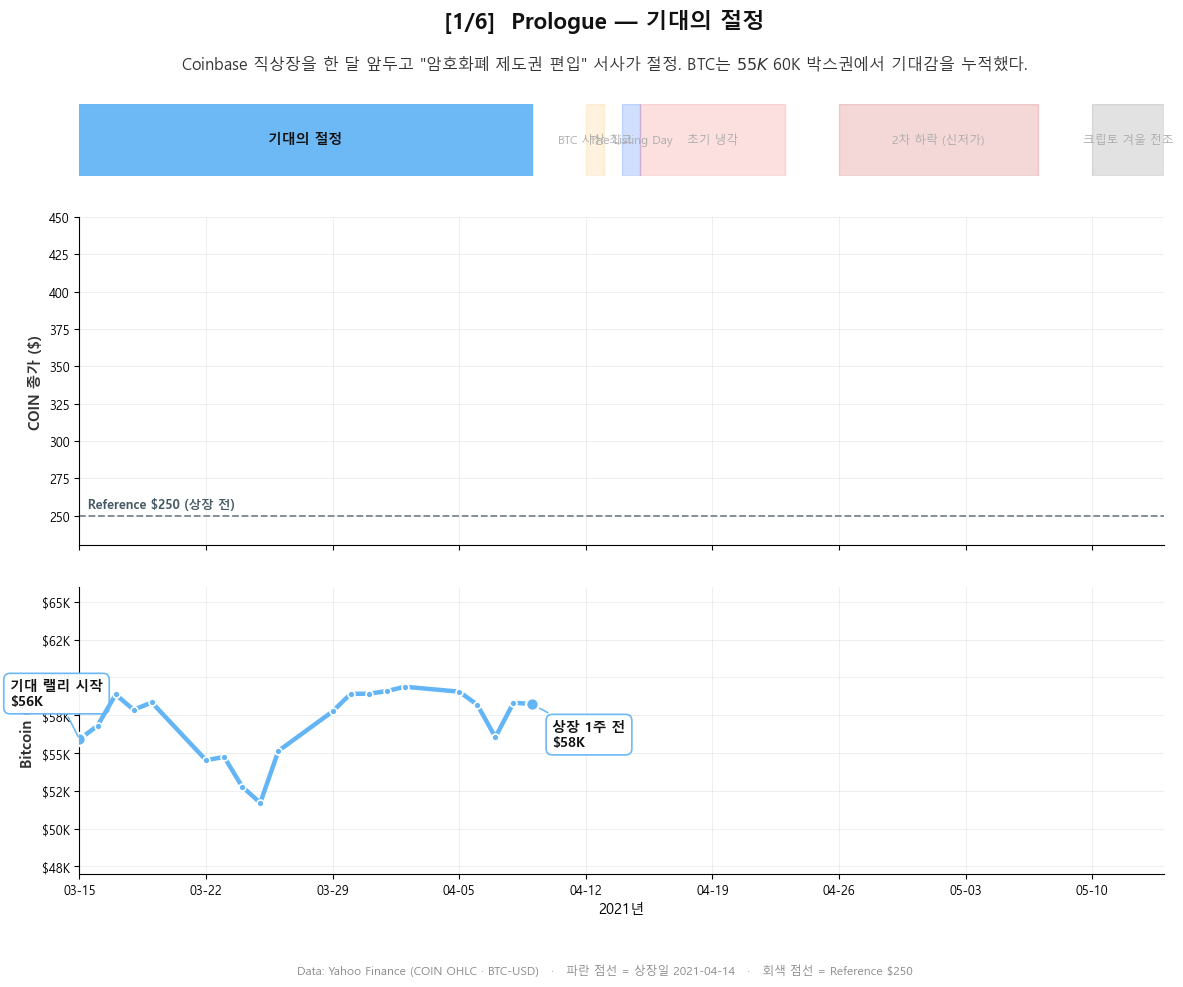

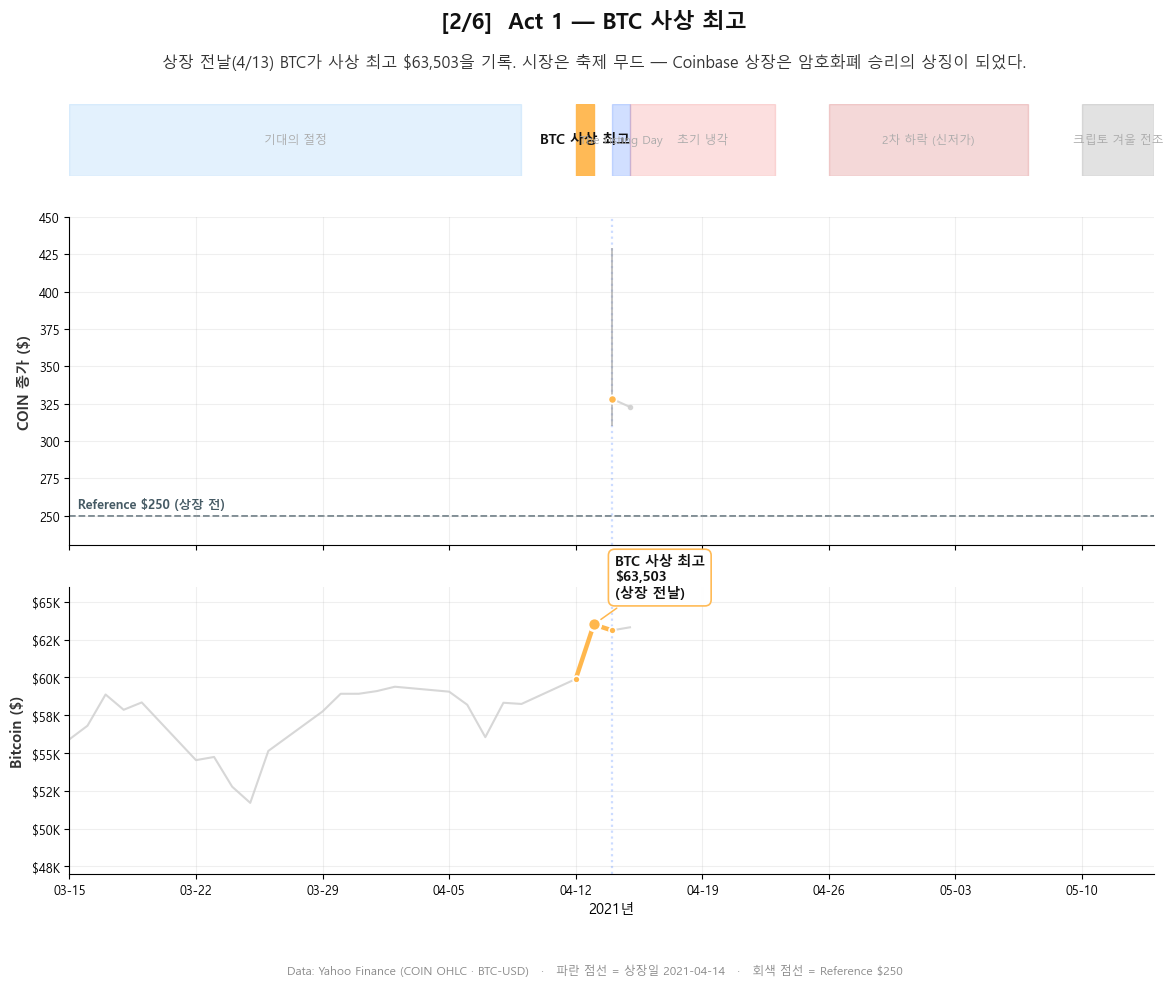

C:\Users\kimch\AppData\Local\Temp\ipykernel_4544\2107311278.py:154: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
c:\Users\kimch\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


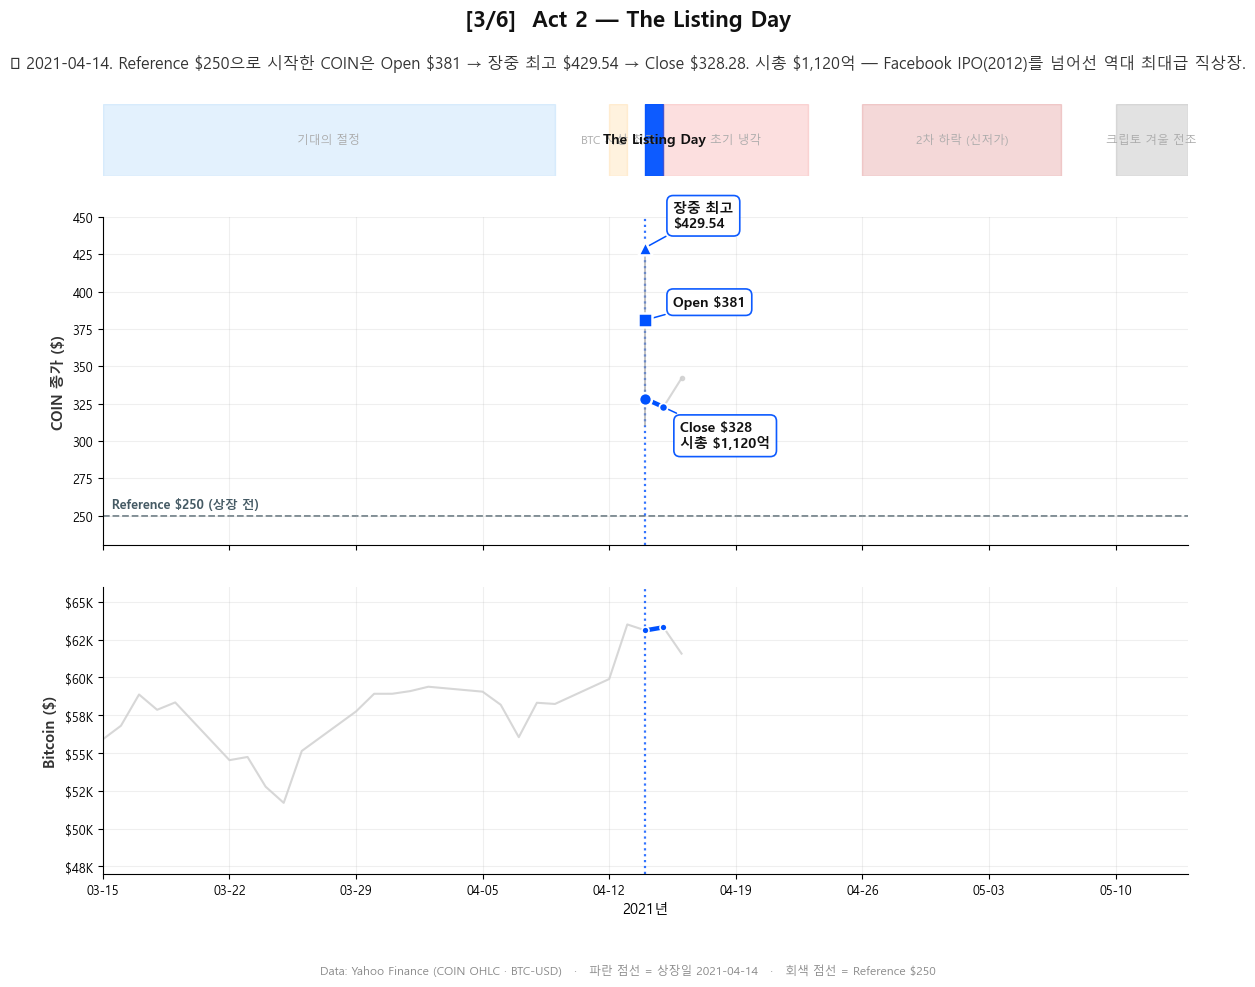

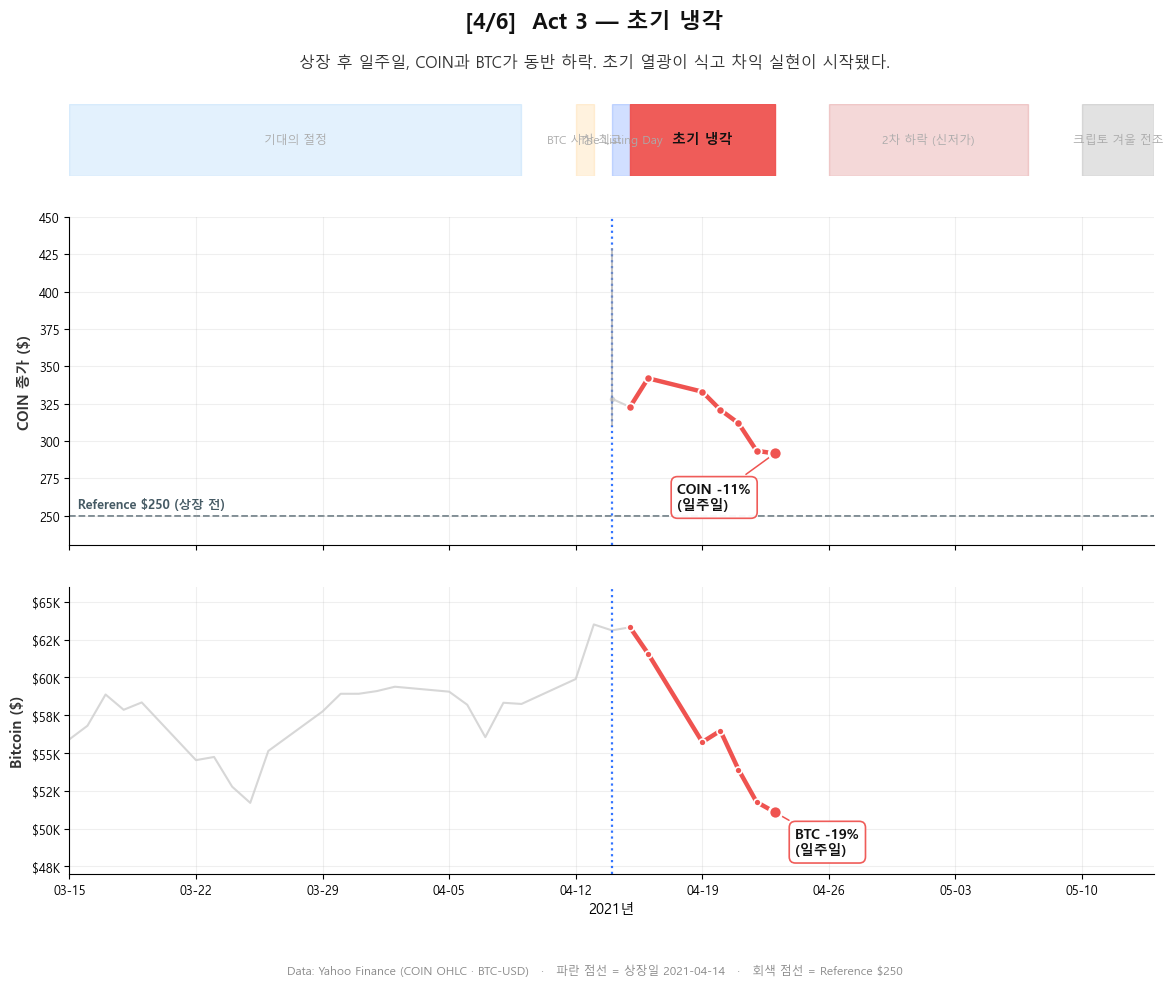

Font 'rm' does not have a glyph for '\uae4c' [U+ae4c], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc9c0' [U+c9c0], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ud558' [U+d558], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ub77d' [U+b77d], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc0c1' [U+c0c1], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc7a5' [U+c7a5], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc77c' [U+c77c], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ub300' [U+b300], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ube44' [U+be44], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uae4c' [U+ae4c], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc9c0' [U+c9c0], substituting with a dummy symbol.
Font 'rm' does not ha

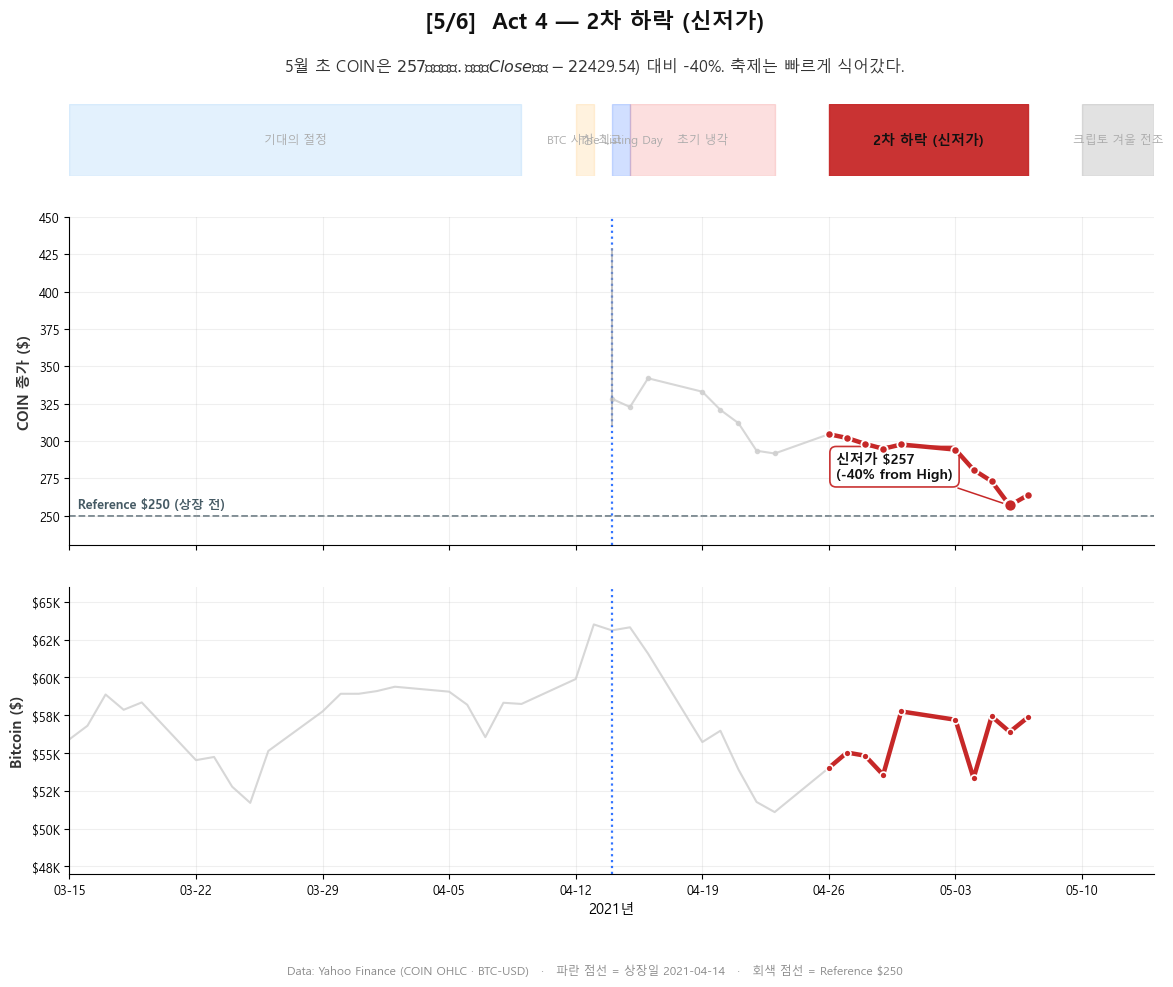

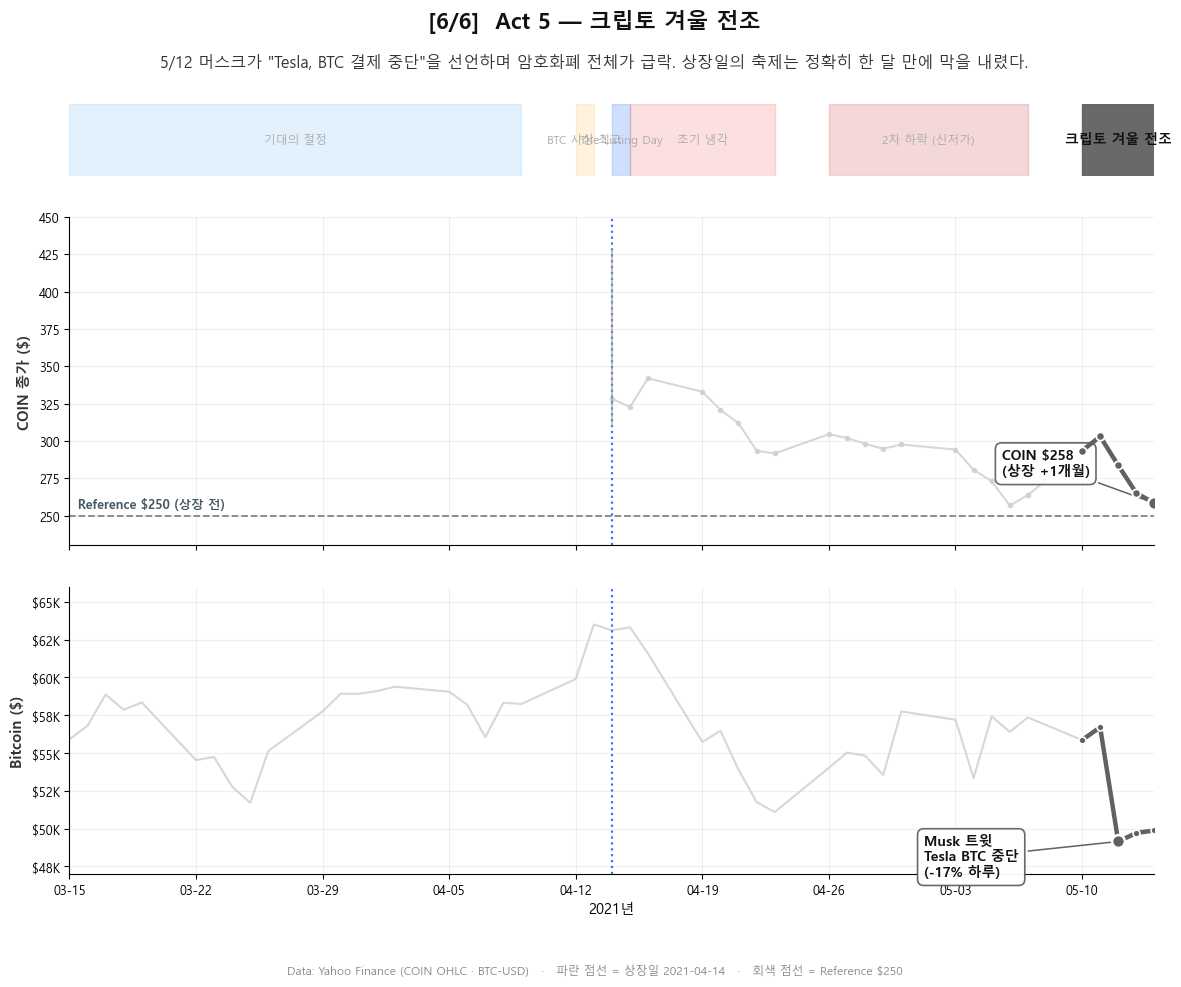


[OK] 저장된 프레임:
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\eA_story\00_prologue.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\eA_story\01_act1.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\eA_story\02_act2.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\eA_story\03_act3.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\eA_story\04_act4.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\eA_story\05_act5.png


In [5]:
saved = []
for i in range(len(phases)):
    fig, path = draw_frame(i)
    saved.append(path)
    plt.show()

print('\n[OK] 저장된 프레임:')
for p in saved:
    print(f'  - {p}')

## 6. 종합 프레임 — 한 장 요약

C:\Users\kimch\AppData\Local\Temp\ipykernel_4544\1702618803.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.92])
Font 'rm' does not have a glyph for '\uc0c1' [U+c0c1], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc7a5' [U+c7a5], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc2dc' [U+c2dc], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ucd1d' [U+cd1d], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc0c1' [U+c0c1], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc7a5' [U+c7a5], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc2dc' [U+c2dc], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\ucd1d' [U+cd1d], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc0c1' [U+c0c1], substitut

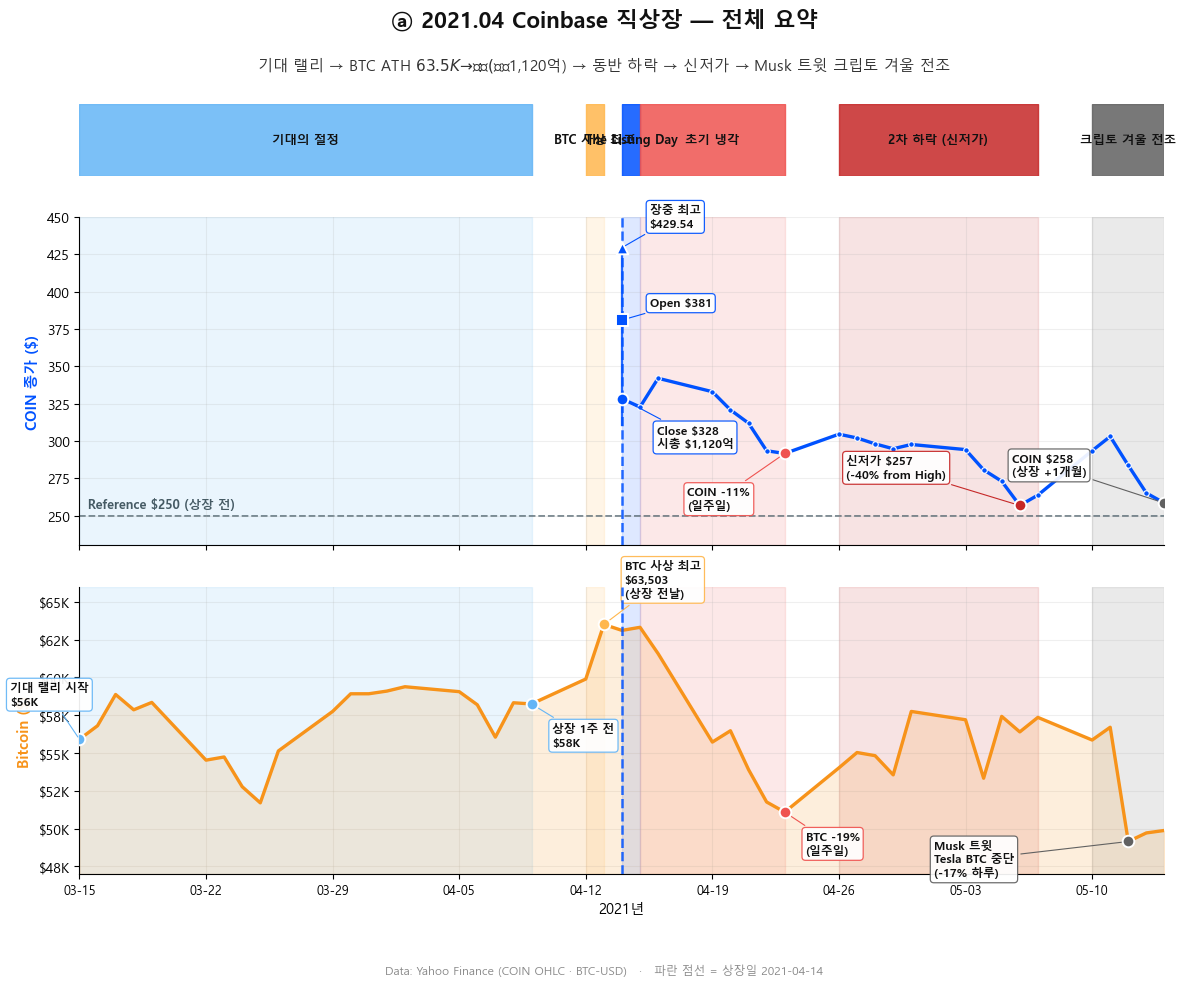


[OK] 종합 프레임: c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\eA_story\99_summary.png


In [6]:
def draw_summary():
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 1, height_ratios=[0.35, 1.6, 1.4], hspace=0.18)
    ax_rib  = fig.add_subplot(gs[0])
    ax_coin = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_btc  = fig.add_subplot(gs[2], sharex=ax_rib)

    # Ribbon
    for p in phases:
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.85)
        short = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short,
                    ha='center', va='center', fontsize=9,
                    fontweight='bold', color='#111')
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top', 'right', 'bottom', 'left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    fig.suptitle('\u24d0 2021.04 Coinbase 직상장 — 전체 요약',
                 fontsize=16, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.93,
             '기대 랠리 → BTC ATH $63.5K → 상장 (시총 $1,120억) → 동반 하락 → 신저가 → Musk 트윗 크립토 겨울 전조',
             ha='center', va='top', fontsize=11, color='#333', style='italic')

    # 국면 배경
    for p in phases:
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        for ax in (ax_coin, ax_btc):
            ax.axvspan(s, e, color=p['color'], alpha=0.13, zorder=0)

    # COIN
    ax_coin.axhline(REF_PRICE, color='#455A64', linestyle='--', lw=1.3, alpha=0.75, zorder=1)
    ax_coin.text(XLIM[0], REF_PRICE + 3, '  Reference $250 (상장 전)',
                 fontsize=9, color='#455A64', fontweight='bold', va='bottom')
    ax_coin.plot(coin.index, coin['Close'], color='#0052FF', lw=2.4,
                 marker='o', markersize=4, markerfacecolor='#0052FF',
                 markeredgecolor='white', markeredgewidth=0.8, zorder=3)
    # 상장일 OHLC 막대
    r0 = coin.loc[LISTING_DATE]
    ax_coin.vlines(LISTING_DATE, r0['Low'], r0['High'], colors='#0052FF',
                   lw=1.6, alpha=0.85, zorder=3)
    ax_coin.set_ylabel('COIN 종가 ($)', fontsize=10.5, fontweight='bold', color='#0052FF')

    # BTC
    ax_btc.plot(btc.index, btc, color='#F7931A', lw=2.4, zorder=3)
    ax_btc.fill_between(btc.index, btc, YLIM_BTC[0], color='#F7931A', alpha=0.15, zorder=2)
    ax_btc.set_ylabel('Bitcoin ($)', fontsize=10.5, fontweight='bold', color='#F7931A')
    ax_btc.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

    for ax in (ax_coin, ax_btc):
        ax.grid(alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax_coin.set_ylim(YLIM_COIN)
    ax_btc.set_ylim(YLIM_BTC)

    # 상장일 수직선
    for ax in (ax_coin, ax_btc):
        ax.axvline(LISTING_DATE, color='#0052FF', linestyle='--', lw=1.8, alpha=0.85, zorder=4)

    # 모든 hero annotations
    axmap = {'COIN': ax_coin, 'COIN_OPEN': ax_coin, 'COIN_HIGH': ax_coin, 'BTC': ax_btc}
    for phase in phases:
        for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
            ax = axmap[target]
            d = pd.Timestamp(date)
            c = phase['color']
            m = 's' if target == 'COIN_OPEN' else ('^' if target == 'COIN_HIGH' else 'o')
            ax.scatter([d], [y], s=70, color=c, zorder=6,
                       edgecolors='white', lw=1.4, marker=m)
            ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                        textcoords='offset points', fontsize=8.5,
                        fontweight='bold', ha=ha, color='#111',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white',
                                  ec=c, alpha=0.92, lw=0.9),
                        arrowprops=dict(arrowstyle='-', color=c, lw=0.8))

    ax_btc.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax_btc.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_btc.tick_params(axis='x', labelsize=9)
    ax_btc.set_xlabel('2021년', fontsize=10.5)
    for ax in (ax_rib, ax_coin):
        plt.setp(ax.get_xticklabels(), visible=False)

    fig.text(0.5, 0.01,
             'Data: Yahoo Finance (COIN OHLC · BTC-USD)   ·   파란 점선 = 상장일 2021-04-14',
             ha='center', fontsize=8.5, color='#888', style='italic')

    plt.tight_layout(rect=[0, 0.02, 1, 0.92])

    out = FIG_DIR / '99_summary.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out


fig, path = draw_summary()
plt.show()
print(f'\n[OK] 종합 프레임: {path}')

## 7. 최종 산출물 목록

In [ ]:
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.relative_to(ROOT)}   ({f.stat().st_size // 1024} KB)')